In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
#데이터 이미지 / 합성곱 신경망
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target),(test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [ ]:
train_input.shape#60000만장*28*28/컬러값없음 이미지 중심/컬러값=>4차원 데이터
train_scaled=train_input.reshape(-1,28,28,1)/255.0#RGB 따로따로
train_scaled.shape#장수,로우,컬럼,컬러 scale#왜1인지
#밀집층과 달리? 리쉐이프 #정규화

(60000, 28, 28, 1)

In [29]:
train_scaled,val_scaled,train_target,val_target=train_test_split(
    train_scaled,train_target,test_size=0.2,random_state=42
)

#첫번째 합성곱 층

In [30]:
model= keras.Sequential()

In [ ]:
model.add(
    keras.layers.Conv2D(#cnn convolution?
        32,
        kernel_size=3,#2차원 합성곱 Ppt,3*3
        activation='relu',#keras.layers
        padding='same',
        input_shape=(28,28,1)#로우,컬럼,패딩값?:합성곱층#채널1개
        #0으로 패딩채움->엣지 계산 잘할수 있음(세임패딩<->밸리드 패딩?)
    )#원래 크기와 똑같이 맞추겠다
)#센터가 출발, 특성맵=>최대풀링: 최대값

In [ ]:
#풀링층
model.add(keras.layers.MaxPool2D(2))

#두번째 합성곱 층

In [ ]:
model.add(
    keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation='relu',
        padding='same'#두번째 합성곱층에는 인풋쉐이프 필요없음
    )#겹쳐서 이동을함. 공부의 목적:커널의 가중치는 같다. 가중치가 다양해짐(추격층? 끝난다음 목차때문에). 이미지가 달라짐.
)#보상받기위해 *2

model.add(keras.layers.MaxPool2D(2))

#완전 연결층(입력데이터)

In [ ]:
#cnn 조각 / 퍼즐 맞추기#고양이 귀
#최대한 작게해서 퍼즐을 만든다. 이미지 분리?
model.add(keras.layers.Flatten())#한줄로 펴짐
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))#Cnn 반드시 데이터 많아 과적합 방지
model.add(keras.layers.Dense(10,activation='softmax'))#fashion_mnist 출력층,10종류

In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#Model Compile 과 훈련

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_cb= keras.callbacks.ModelCheckpoint("../Data/best_model.keras")
early_stopping_cb= keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True)#early stopping=>patience
#에포크 작게 할필요없음. 보통 첫번째 에포크의 정확도는 높지않음.    
history=model.fit(train_scaled,train_target,epochs=20, validation_data=(val_scaled,val_target),callbacks=[checkpoint_cb,early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6586 - loss: 0.9076 - val_accuracy: 0.8468 - val_loss: 0.4327
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.7507 - loss: 0.6526 - val_accuracy: 0.8692 - val_loss: 0.3545
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7785 - loss: 0.5829 - val_accuracy: 0.8848 - val_loss: 0.3233
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7941 - loss: 0.5323 - val_accuracy: 0.8899 - val_loss: 0.2992
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8111 - loss: 0.4983 - val_accuracy: 0.8913 - val_loss: 0.2992
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8216 - loss: 0.4719 - val_accuracy: 0.8968 - val_loss: 0.2814
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8319 - loss: 0.4458 - val_accuracy: 0.9056 - val_loss: 0.2626
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8420 -

In [37]:
import matplotlib.pyplot as plt

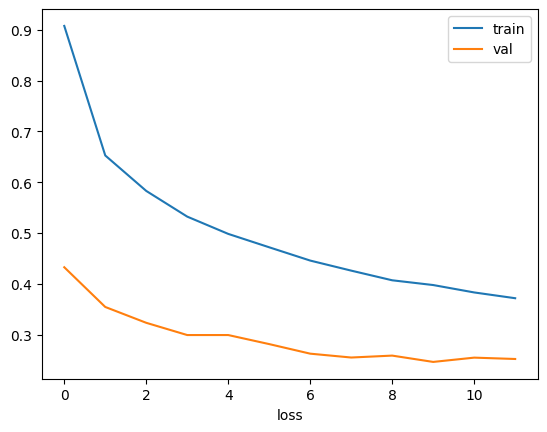

In [ ]:
#시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

#평가와 예측

In [40]:
#검증 데이터
model.evaluate(val_scaled,val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9140 - loss: 0.2464


[0.24635927379131317, 0.9139999747276306]

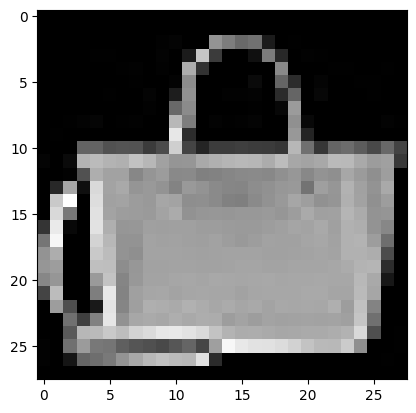

In [44]:
#이미지 확인하기
plt.imshow(val_scaled[0].reshape(28, 28),cmap='gray')
plt.show()

In [ ]:
preds=model.predict(val_scaled[0:0+1])
print(preds)#차원이 다름#인덱스:데이터만 타입없음 슬라이싱:타입 가지고 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[6.481022e-36 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  8.460984e-34 1.912004e-29 0.000000e+00 1.000000e+00 0.000000e+00]]


In [ ]:
#글자로 변경하기
import numpy as np
classes=['티셔츠','바지','스웨터','드레스','코트','샌달','셔츠','스니커즈','가방','앵글부츠']

print(classes[np.argmax(preds)])#preds의 가장 높은 값의 인덱스 값

가방


In [ ]:
#나눠서 학습 cnn:영상 전처리
#cnn:전체 이미지를 분리시켜서 학습=>이미지 생성
#fully connected dense층
#RGB:2=>4차원
#특성 맵 크기가 커지면 스크래치가 크게 느껴짐, 작게 만드는 것이 좋다.
#3*3 이미지를 작게 잡는다.
#합성곱층+pooling층
#이미지가 커지면 5단계